##Credits : https://github.com/nabenabe0928/empirical-attainment-func

In [113]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from adjustText import adjust_text
import eaf

In [114]:
from eaf import get_empirical_attainment_surface, EmpiricalAttainmentFuncPlot

In [115]:
sensitivity= "outputs/ddim_inference_experiment_results_all.csv"

In [116]:
sensitivity_df = pd.read_csv(sensitivity)

In [117]:
print(sensitivity_df.columns)

Index(['denoising_steps', 'num_samples', 'inference_time_mins', 'nc_file',
       'SSIM_temp_DDIM', 'SSIM_precip_DDIM', 'CRPS_temp_DDIM',
       'CRPS_precip_DDIM', 'SSIM_temp_UNet', 'SSIM_precip_UNet',
       'CRPS_temp_UNet', 'CRPS_precip_UNet'],
      dtype='object')


In [118]:
cols = ['CRPS_precip_DDIM', 'CRPS_temp_DDIM']
for col in cols: 
    col_min = sensitivity_df[col].min()
    col_max = sensitivity_df[col].max()
    sensitivity_df[col +"_normalised_CRPS"]= (sensitivity_df[col] - col_min) / (col_max - col_min)

In [119]:
texts = []

fig,ax = plt.subplots(figsize=(12, 8), dpi=1000)


ax.scatter(sensitivity_df["CRPS_precip_DDIM_normalised_CRPS"], sensitivity_df["inference_time_mins"], alpha=0.5, 
            color='blue',
            s=15) 




ax.scatter(sensitivity_df["CRPS_temp_DDIM_normalised_CRPS"], sensitivity_df["inference_time_mins"], alpha=0.5,
            color='red',
            s=15)




for i in range(len(sensitivity_df)):
    label = f"({int(sensitivity_df['num_samples'].iloc[i])}, {int(sensitivity_df['denoising_steps'].iloc[i])})"



    texts.append(ax.text(
        sensitivity_df["CRPS_precip_DDIM_normalised_CRPS"].iloc[i],
        sensitivity_df["inference_time_mins"].iloc[i],
        label, fontsize=8, color="blue",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=0.2)
    ))

    texts.append(ax.text(
        sensitivity_df["CRPS_temp_DDIM_normalised_CRPS"].iloc[i],
        sensitivity_df["inference_time_mins"].iloc[i],
        label, fontsize=8, color="red",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=0.2)
    ))

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.8),
    expand_points=(1.2, 1.4),
    expand_text=(1.2, 1.4)
)





([Text(0.6054244699374038, 52.118282857221374, '(2, 100)'),
  Text(0.9254270849211162, 52.118282857221374, '(2, 100)'),
  Text(0.25105273557192304, 101.02349533506435, '(4, 100)'),
  Text(0.3959477308450363, 101.02349533506435, '(4, 100)'),
  Text(0.02888169289446929, 125.5658404057049, '(15, 30)'),
  Text(0.004435483870967816, 134.5426069292316, '(15, 30)'),
  Text(1.0200557795698924, 11.546410125906135, '(2, 10)'),
  Text(0.9779684945059798, 11.608748782319509, '(2, 10)'),
  Text(0.5845159791557875, 15.983186267497146, '(2, 20)'),
  Text(0.7602150966987896, 12.928592103241542, '(2, 20)'),
  Text(0.049765305915450087, 257.4366715260677, '(10, 100)'),
  Text(0.10505911770573156, 252.69893363865083, '(10, 100)'),
  Text(0.2340453007829415, 33.258133911734475, '(4, 30)'),
  Text(0.32383236173640273, 37.24780792219079, '(4, 30)'),
  Text(0.08754490514526281, 97.1892695178434, '(15, 20)'),
  Text(0.023985515643578426, 93.88532072793427, '(15, 20)'),
  Text(0.6856890697007526, 17.7724638762

In [120]:
def pareto_minimise(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:

    points = df[[x_col, y_col]].to_numpy()
    is_pareto = np.ones(len(points), dtype=bool)

    for i in range(len(points)):
        for j in range(len(points)):
            if i != j:
                if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                    is_pareto[i] = False
                    break

    front = df.loc[is_pareto].copy()
    return front.sort_values([x_col, y_col]).reset_index(drop=True)


In [121]:
precip_col = "CRPS_precip_DDIM_normalised_CRPS"
temp_col = "CRPS_temp_DDIM_normalised_CRPS"
time_col = "inference_time_mins"

In [122]:
precip_front = pareto_minimise(sensitivity_df, precip_col, time_col)
temp_front = pareto_minimise(sensitivity_df, temp_col, time_col)


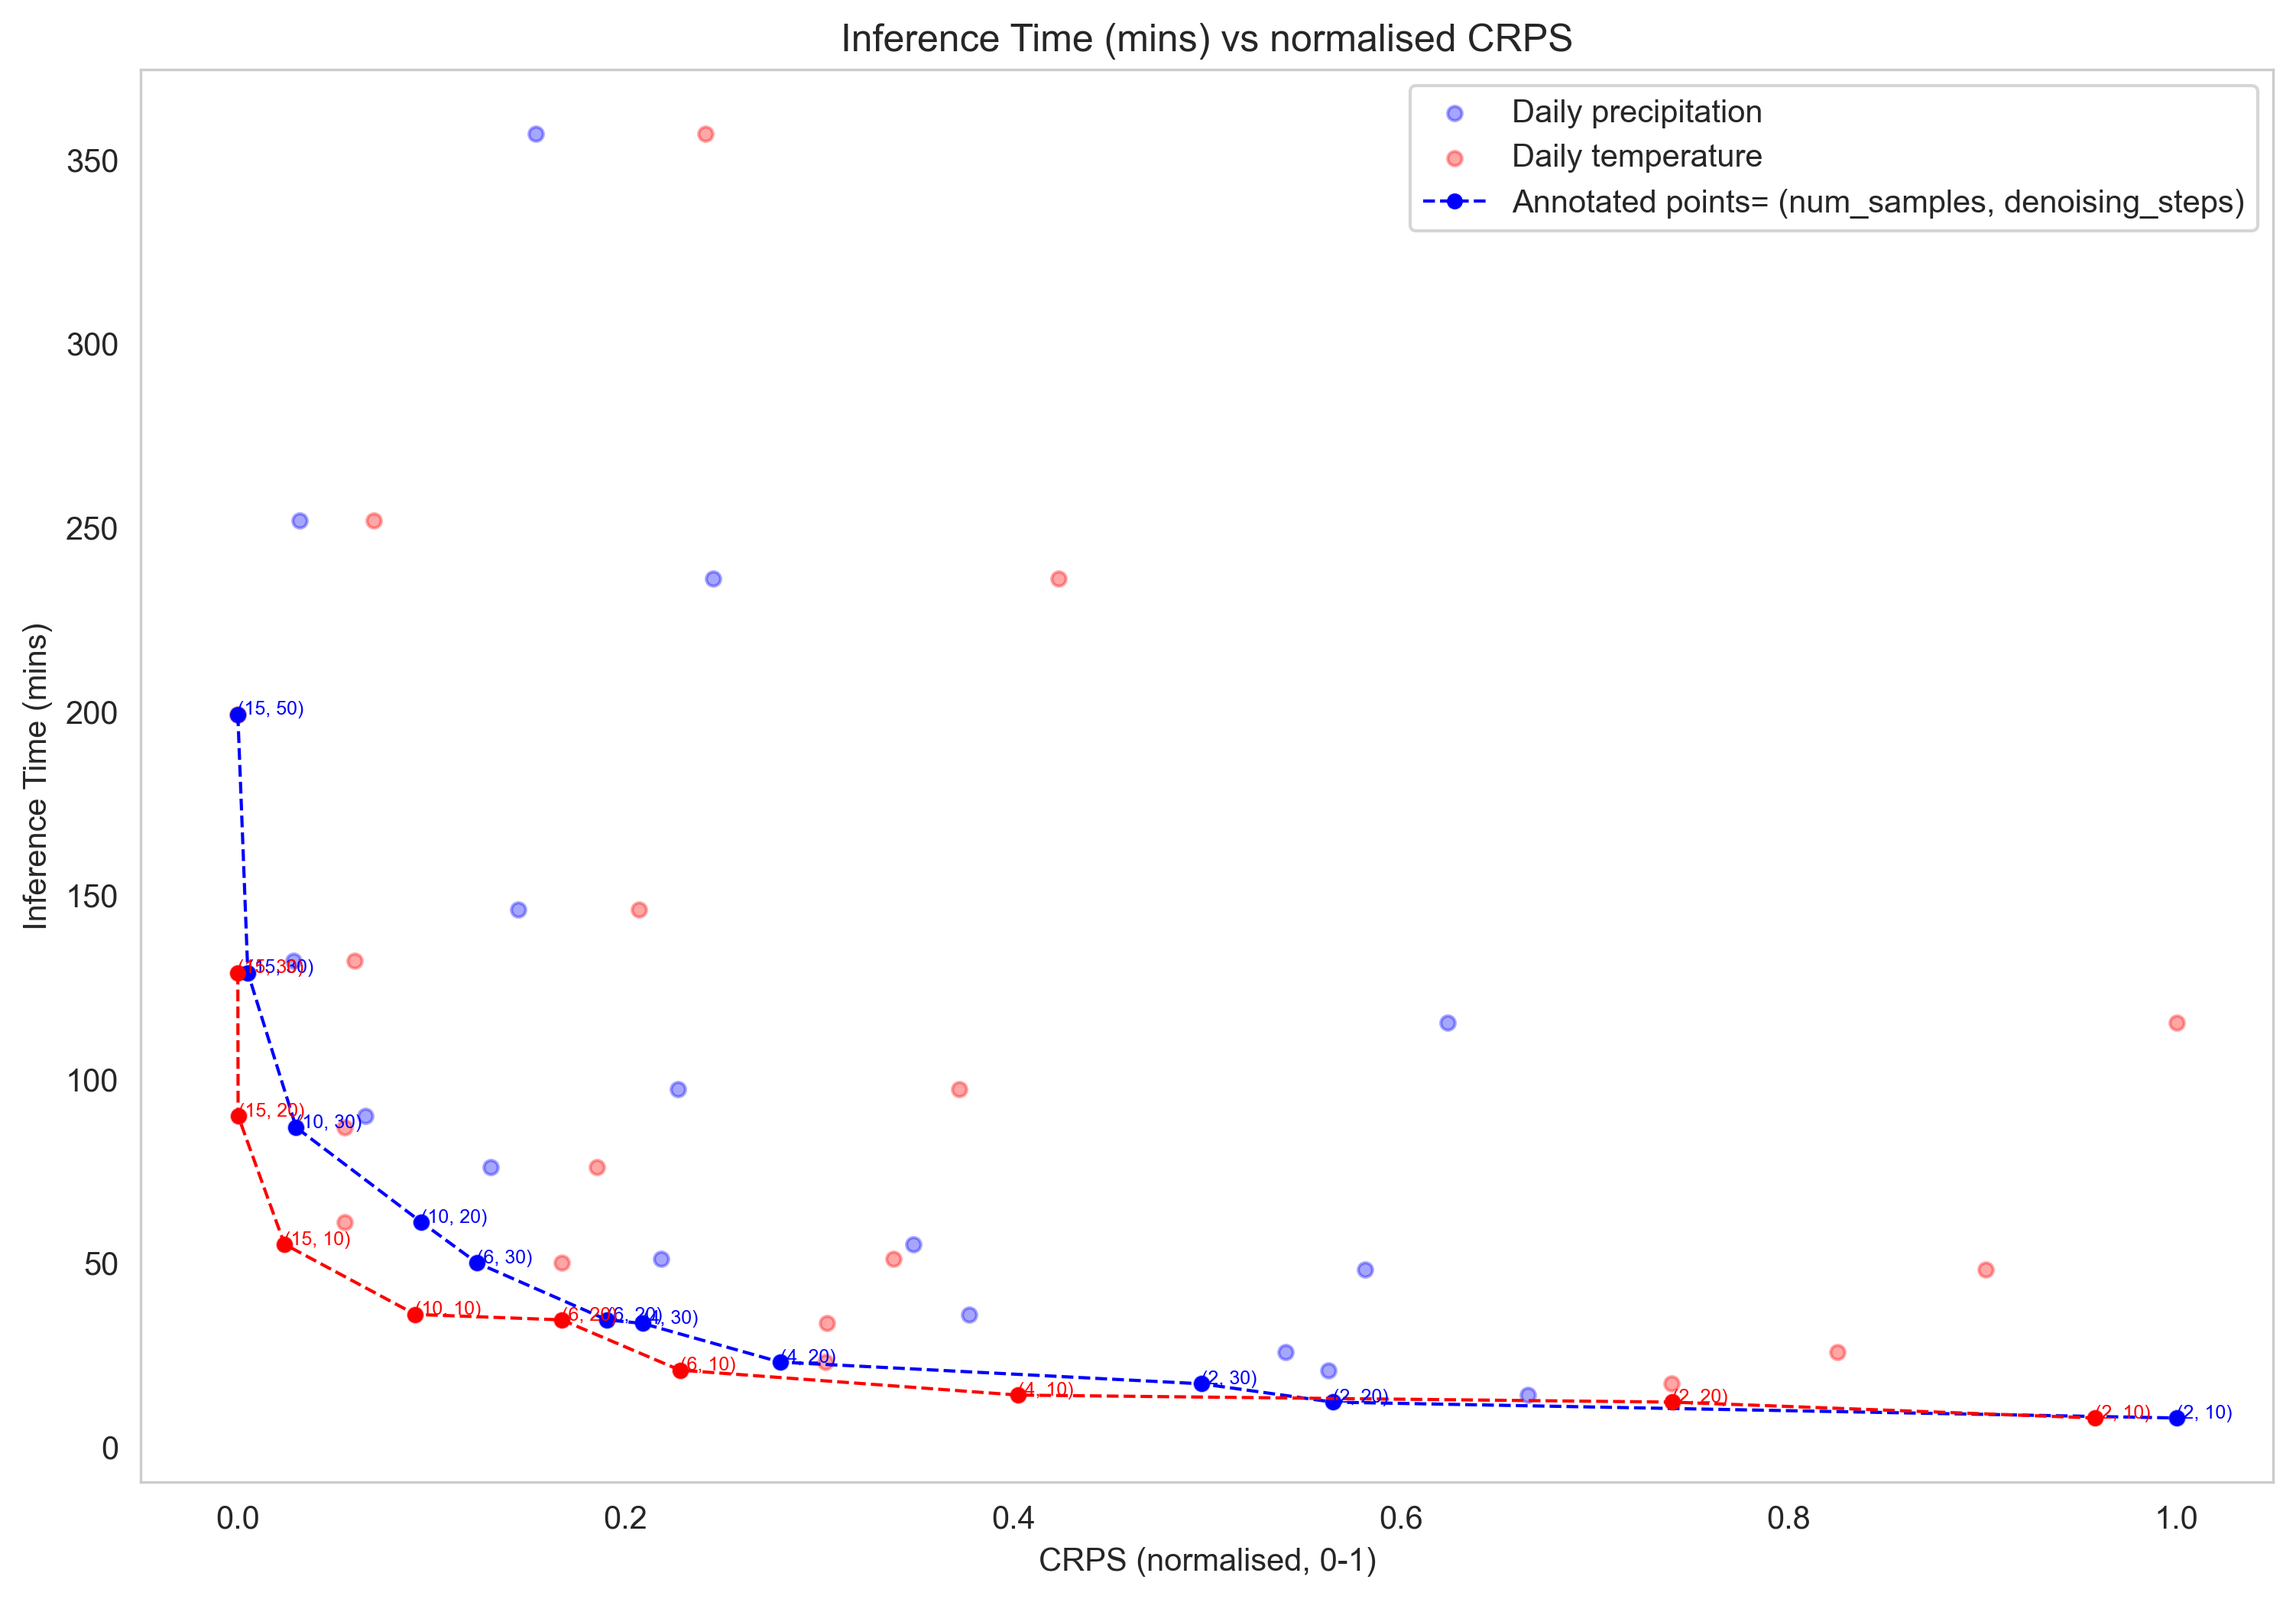

In [123]:
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

ax.scatter(
    sensitivity_df[precip_col],
    sensitivity_df[time_col],
    color="blue",
    alpha=0.35,
    s=20,
    label="Precipitation (mm/day)"
)

ax.scatter(
    sensitivity_df[temp_col],
    sensitivity_df[time_col],
    color="red",
    alpha=0.35,
    s=20,
    label="Temperature (°C)"
)

ax.plot(
    precip_front[precip_col],
    precip_front[time_col],
    color="blue",
    marker="o",
    linestyle="--",
    linewidth=1,
    markersize=4,
    label="Precipitation Pareto front"
)

ax.plot(
    temp_front[temp_col],
    temp_front[time_col],
    color="red",
    marker="o",
    linestyle="--",
    linewidth=1,
    markersize=4,
    label="Temperature Pareto front"
)




for _, row in precip_front.iterrows():
    ax.text(
        row[precip_col],
        row[time_col],
        f"({int(row['num_samples'])}, {int(row['denoising_steps'])})",
        fontsize=6,
        color="blue"
    )



for _, row in temp_front.iterrows():
    ax.text(
        row[temp_col],
        row[time_col],
        f"({int(row['num_samples'])}, {int(row['denoising_steps'])})",
        fontsize=6,
        color="red"
    )

ax.set_xlabel("CRPS (normalised, 0-1)")
ax.set_ylabel("Inference Time (mins)")
ax.set_title("Inference Time (mins) vs normalised CRPS")
ax.legend(["Daily precipitation", "Daily temperature", "Annotated points= (num_samples, denoising_steps)"])
ax.grid(False)
plt.savefig("outputs/inference_time_vs_crps_pareto_elbow.pdf", dpi=1000)
plt.show()